# ElSherief Formatting Notebook

This notebook formats the **ElSherief implicit hate corpus** into the shared post-level schema used by downstream union/dedup steps.

## What this notebook does
1. Loads `implicit_hate_v1_stg1_posts.tsv` for post text and high-level class labels.
2. Loads `implicit_hate_v1_stg3_posts.tsv` for target annotations and implied statements.
3. Aggregates stage-3 target annotations by post and merges them onto the stage-1 post table.
4. Maps raw columns to standardized columns.
5. Normalizes targets and text-dedup keys.
6. Saves output to `outputs/preprocessing/03_elsherief_standardized.tsv`.

## Important ElSherief design choice
- `stg1_posts` is treated as the base dataset because it contains the class label needed for binary hate mapping.
- `stg3_posts` is used to recover target annotations.
- Posts with no stage-3 target annotation are kept and assigned the target label `unknown`.

## Output schema
- `post_id`
- `text`
- `raw_label`
- `binary_hate`
- `targets`
- `dataset`
- `text_dedup_key`

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import List, Optional
import json
import re

import pandas as pd

# Resolve workspace root robustly for both editor and command-line execution.
WORKDIR = Path.cwd()
if not (WORKDIR / 'data').exists():
    WORKDIR = Path('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles')

@dataclass
class ElSheriefConfig:
    # Stage 1 provides post text plus the high-level class label.
    stg1_posts_path: Path = WORKDIR / 'data' / 'implicit-hate-corpus' / 'implicit_hate_v1_stg1_posts.tsv'

    # Stage 3 provides target annotations and implied statements for a subset of posts.
    stg3_posts_path: Path = WORKDIR / 'data' / 'implicit-hate-corpus' / 'implicit_hate_v1_stg3_posts.tsv'

    # Shared-schema output location.
    output_path: Path = WORKDIR / 'outputs' / 'preprocessing' / '03_elsherief_standardized.tsv'

cfg = ElSheriefConfig()
cfg.output_path.parent.mkdir(parents=True, exist_ok=True)
cfg

ElSheriefConfig(stg1_posts_path=PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/data/implicit-hate-corpus/implicit_hate_v1_stg1_posts.tsv'), stg3_posts_path=PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/data/implicit-hate-corpus/implicit_hate_v1_stg3_posts.tsv'), output_path=PosixPath('/Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/03_elsherief_standardized.tsv'))

In [2]:
def normalize_text_for_dedup(text: str) -> str:
    """Create a lowercase, whitespace-normalized text key for dedup fallback."""
    if not isinstance(text, str):
        return ''
    return re.sub(r'\s+', ' ', text.strip().lower())


def normalize_target_token(token: str) -> Optional[str]:
    """Normalize one target token to a stable lowercase form."""
    if token is None:
        return None
    value = str(token).strip().lower().replace('_', ' ')
    if not value or value in {'none', 'null', 'nan'}:
        return None
    return value


def parse_targets_generic(value) -> List[str]:
    """Normalize mixed target payloads into a clean list[str]."""
    if value is None:
        return []

    if isinstance(value, (list, tuple, set)):
        candidates = list(value)
    elif isinstance(value, str):
        s = value.strip()
        if not s:
            return []
        if s.startswith('[') and s.endswith(']'):
            try:
                parsed = json.loads(s.replace("'", '"'))
                candidates = parsed if isinstance(parsed, list) else [parsed]
            except Exception:
                candidates = [s]
        elif '|' in s:
            candidates = [x.strip() for x in s.split('|')]
        elif ',' in s:
            candidates = [x.strip() for x in s.split(',')]
        else:
            candidates = [s]
    else:
        try:
            if pd.isna(value):
                return []
        except Exception:
            pass
        candidates = [value]

    normalized = []
    for candidate in candidates:
        token = normalize_target_token(candidate)
        if token:
            normalized.append(token)
    return sorted(set(normalized))


def label_to_binary(label_value) -> Optional[int]:
    """Map ElSherief class labels to the shared binary hate label."""
    if label_value is None:
        return None

    try:
        if pd.isna(label_value):
            return None
    except Exception:
        pass

    s = str(label_value).strip().lower()

    # Both implicit and explicit hate are treated as positive in the shared schema.
    if s in {'hate', 'hateful', 'hatespeech', 'implicit_hate', 'explicit_hate', '1', 'true', 'yes'}:
        return 1
    if s in {'normal', 'non-hate', 'non_hate', 'not_hate', '0', 'false', 'no'}:
        return 0
    return None


def serialize_targets_for_tsv(value) -> str:
    """Serialize list-like targets as pipe-delimited strings for TSV output."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return ''
    if isinstance(value, list):
        return '|'.join(str(x) for x in value)
    return str(value)


def read_elsherief_merged(stg1_posts_path: Path, stg3_posts_path: Path) -> pd.DataFrame:
    """Load stage-1 and stage-3 post files and merge target annotations onto labeled posts."""
    if not stg1_posts_path.exists():
        raise FileNotFoundError(f'Missing ElSherief stage-1 posts file: {stg1_posts_path}')
    if not stg3_posts_path.exists():
        raise FileNotFoundError(f'Missing ElSherief stage-3 posts file: {stg3_posts_path}')

    stg1 = pd.read_csv(stg1_posts_path, sep='\t')
    stg3 = pd.read_csv(stg3_posts_path, sep='\t')

    required_stg1 = {'post', 'class'}
    required_stg3 = {'post', 'target'}
    missing_stg1 = required_stg1 - set(stg1.columns)
    missing_stg3 = required_stg3 - set(stg3.columns)
    if missing_stg1:
        raise KeyError(f'ElSherief stage-1 posts file missing columns: {sorted(missing_stg1)}')
    if missing_stg3:
        raise KeyError(f'ElSherief stage-3 posts file missing columns: {sorted(missing_stg3)}')

    # Stage 3 can have multiple target annotations per post, so aggregate them before merging.
    stg3_agg = (
        stg3.groupby('post', dropna=False)
        .agg(
            targets=('target', lambda s: sorted(set(t for value in s for t in parse_targets_generic(value)))),
            implied_statements=(
                'implied_statement',
                lambda s: sorted(
                    set(
                        str(value).strip()
                        for value in s
                        if value is not None and not (isinstance(value, float) and pd.isna(value)) and str(value).strip()
                    )
                ),
            ),
        )
        .reset_index()
    )

    merged = stg1.merge(stg3_agg, on='post', how='left')

    # Preserve all labeled posts; posts without stage-3 targets are explicitly marked as unknown.
    merged['targets'] = merged['targets'].apply(
        lambda value: value if isinstance(value, list) and len(value) > 0 else ['unknown']
    )
    return merged

In [3]:
def harmonize_elsherief(df: pd.DataFrame) -> pd.DataFrame:
    """Map merged ElSherief stage-1/stage-3 fields into the common standardized schema."""
    required = ['post', 'class']
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise KeyError(f'ElSherief merged dataframe missing columns: {missing}')

    out = pd.DataFrame()

    # The `_posts` files do not expose stable IDs, so create a deterministic row-based post ID.
    out['post_id'] = pd.Series(df.index).astype(str)

    # Stage-1 posts file provides the text content directly in the `post` column.
    out['text'] = df['post'].astype(str)

    # Preserve stage-1 class label and map it to the shared binary hate label.
    out['raw_label'] = df['class']
    out['binary_hate'] = df['class'].apply(label_to_binary).astype('Int64')

    # Use merged stage-3 targets where available; otherwise keep the explicit `unknown` fallback.
    if 'targets' in df.columns:
        out['targets'] = df['targets'].apply(
            lambda value: value if isinstance(value, list) and len(value) > 0 else ['unknown']
        )
    elif 'target' in df.columns:
        out['targets'] = df['target'].apply(lambda value: parse_targets_generic(value) or ['unknown'])
    else:
        out['targets'] = [['unknown'] for _ in range(len(df))]

    out['dataset'] = 'elsherief'
    out['text_dedup_key'] = out['text'].apply(normalize_text_for_dedup)

    # Keep one row per generated post ID in final standardized export.
    out = out.drop_duplicates(subset=['post_id'], keep='first').copy()
    return out


def dataframe_for_tsv(df: pd.DataFrame) -> pd.DataFrame:
    """Convert list columns into stable string-safe TSV representations."""
    export_df = df.copy()
    export_df['targets'] = export_df['targets'].apply(serialize_targets_for_tsv)
    return export_df

In [4]:
els_raw = read_elsherief_merged(cfg.stg1_posts_path, cfg.stg3_posts_path)
els_std = harmonize_elsherief(els_raw)
els_std_tsv = dataframe_for_tsv(els_std)

els_std_tsv.to_csv(cfg.output_path, sep='\t', index=False)

print('Saved ElSherief standardized output to:', cfg.output_path)
print('Rows written:', len(els_std_tsv))
print('Rows with unknown target fallback:', int(els_std["targets"].apply(lambda value: value == ["unknown"]).sum()))
display(els_std.head(3))

Saved ElSherief standardized output to: /Users/RevaH/Documents/COS534/benchmarking_dogwhistles/outputs/preprocessing/03_elsherief_standardized.tsv
Rows written: 21480
Rows with unknown target fallback: 15284


,post_id,text,raw_label,binary_hate,targets,dataset,text_dedup_key
0,0,""" : jewish harvard professor noel ignatiev w...",implicit_hate,1,[unknown],elsherief,""" : jewish harvard professor noel ignatiev wan..."
1,1,b.higher education is a part of european cult...,not_hate,0,[unknown],elsherief,b.higher education is a part of european cultu...
2,2,"has a problem with "" the whites "" "" and "" "" ...",not_hate,0,[unknown],elsherief,"has a problem with "" the whites "" "" and "" "" th..."


Target label distribution (count and percentage):


,target_label,count,percentage
0,unknown,15284,71.07
1,immigrants,821,3.82
2,white people,738,3.43
3,minorities,709,3.30
4,muslims,594,2.76
...,...,...,...
558,a woman,1,0.00
559,brown and white people,1,0.00
560,non-patriotic people,1,0.00
561,not specified in this tweet,1,0.00


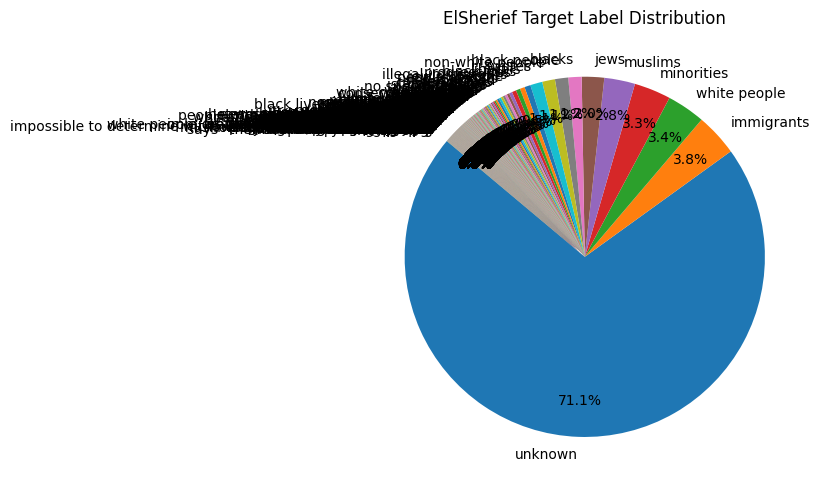

In [5]:
# Groupwise target-label summary for ElSherief.
# Note: in this dataset, rows are effectively binary_hate == 1, so a single table/plot is sufficient.

import matplotlib.pyplot as plt
from IPython.display import display


def build_target_distribution(df: pd.DataFrame, targets_col: str = 'targets') -> pd.DataFrame:
    """Return count/percentage distribution from mixed target representations."""
    flat_labels = []

    for value in df[targets_col]:
        # parse_targets_generic handles list, tuple, set, plain strings, and list-like strings.
        labels = parse_targets_generic(value)
        if labels:
            flat_labels.extend(labels)

    if not flat_labels:
        return pd.DataFrame(columns=['target_label', 'count', 'percentage'])

    dist = pd.Series(flat_labels).value_counts().rename_axis('target_label').reset_index(name='count')
    dist['percentage'] = (dist['count'] / dist['count'].sum() * 100).round(2)
    return dist


# Build one distribution from the full standardized dataframe.
work_df = els_std.copy()
work_df['binary_hate'] = pd.to_numeric(work_df['binary_hate'], errors='coerce').astype('Int64')

target_dist = build_target_distribution(work_df)

print('Target label distribution (count and percentage):')
display(target_dist)

# Single pie chart for overall target composition.
plt.figure(figsize=(8, 8))
if not target_dist.empty:
    plt.pie(
        target_dist['count'],
        labels=target_dist['target_label'],
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.8,
    )
    plt.title('ElSherief Target Label Distribution')
else:
    plt.text(0.5, 0.5, 'No target labels', ha='center', va='center')
    plt.title('ElSherief Target Label Distribution')

plt.tight_layout()
plt.show()